<a href="https://colab.research.google.com/github/sudoice/btpii/blob/main/notebooks/paper_plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparison Plots

This notebook generates the plots for comparing:
1. **Baseline TD3** (NOMA=False, TOPSIS=False)
2. **TD3 + NOMA** (NOMA=True, TOPSIS=False)
3. **TD3 + TOPSIS** (NOMA=False, TOPSIS=True)
4. **Integrated TD3 + NOMA + TOPSIS** (NOMA=True, TOPSIS=True)

## How to Run
1. Fill in the 4 Google Drive paths in Cell 2
2. Run All Cells
3. All plots are saved as high-resolution PNGs to your Drive

In [2]:
# Cell 1: Mount Drive & Imports
from google.colab import drive
drive.mount('/content/drive')

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os

# Publication-quality settings
matplotlib.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

print('Ready!')

Mounted at /content/drive
Ready!


In [6]:
# Cell 2: CONFIGURE YOUR PATHS HERE
# ===================================
# Point each to the folder containing training_metrics.json and evaluation_results.json

# Select MAP1 or MAP2
map_name = 'MAP1'
res_loc = '/content/drive/MyDrive/RESULTS/'+map_name

PATHS = {
    'Baseline TD3':       res_loc+'/TD3',      # NOMA=F, TOPSIS=F
    'TD3 + NOMA':      res_loc+'/NOMA_TD3',         # NOMA=T, TOPSIS=F  <-- UPDATE THIS
    'TD3 + TOPSIS':    res_loc+'/TD3_TOPSIS',     # NOMA=F, TOPSIS=T  <-- UPDATE THIS
    'TD3 + NOMA + TOPSIS':    res_loc+'/NOMA_TD3_TOPSIS',  # NOMA=T, TOPSIS=T
}

# Where to save output plots
SAVE_DIR = '/content/drive/MyDrive/PLOTS/'+map_name
os.makedirs(SAVE_DIR, exist_ok=True)

# Load all data
train_data = {}
eval_data = {}

for name, path in PATHS.items():
    tm = os.path.join(path, 'training_metrics.json')
    er = os.path.join(path, 'evaluation_results.json')

    if os.path.exists(tm):
        with open(tm) as f:
            train_data[name] = json.load(f)
        print(f'Loaded training metrics: {name} ({len(train_data[name]["episode_rewards"])} episodes)')
    else:
        print(f'WARNING: Training metrics not found for {name} at {tm}')

    if os.path.exists(er):
        with open(er) as f:
            eval_data[name] = json.load(f)
        print(f'Loaded evaluation results: {name} (mean_reward={eval_data[name]["mean_reward"]:.2f})')
    else:
        print(f'WARNING: Evaluation results not found for {name} at {er}')

print(f'\nLoaded {len(train_data)} training + {len(eval_data)} evaluation datasets')

Loaded training metrics: Baseline TD3 (5000 episodes)
Loaded evaluation results: Baseline TD3 (mean_reward=-206.59)
Loaded training metrics: TD3 + NOMA (5000 episodes)
Loaded evaluation results: TD3 + NOMA (mean_reward=-168.66)
Loaded training metrics: TD3 + TOPSIS (5000 episodes)
Loaded evaluation results: TD3 + TOPSIS (mean_reward=-191.81)
Loaded training metrics: TD3 + NOMA + TOPSIS (5000 episodes)
Loaded evaluation results: TD3 + NOMA + TOPSIS (mean_reward=-155.45)

Loaded 4 training + 4 evaluation datasets


In [14]:
# Cell 3: Helper — smoothing function for training curves
def smooth(data, window=50):
    """Moving average smoothing for noisy training curves."""
    if len(data) < window:
        return data
    kernel = np.ones(window) / window
    return np.convolve(data, kernel, mode='valid')

# Colors for consistent styling across all plots
COLORS = {
    'Baseline TD3':    '#1f77b4',  # Blue
    'TD3 + NOMA':   '#ff7f0e',  # Orange
    'TD3 + TOPSIS': '#2ca02c',  # Green
    'TD3 + NOMA + TOPSIS': '#d62728',  # Red
}

print('Helpers ready')

Helpers ready


---
## Training Convergence (Reward)

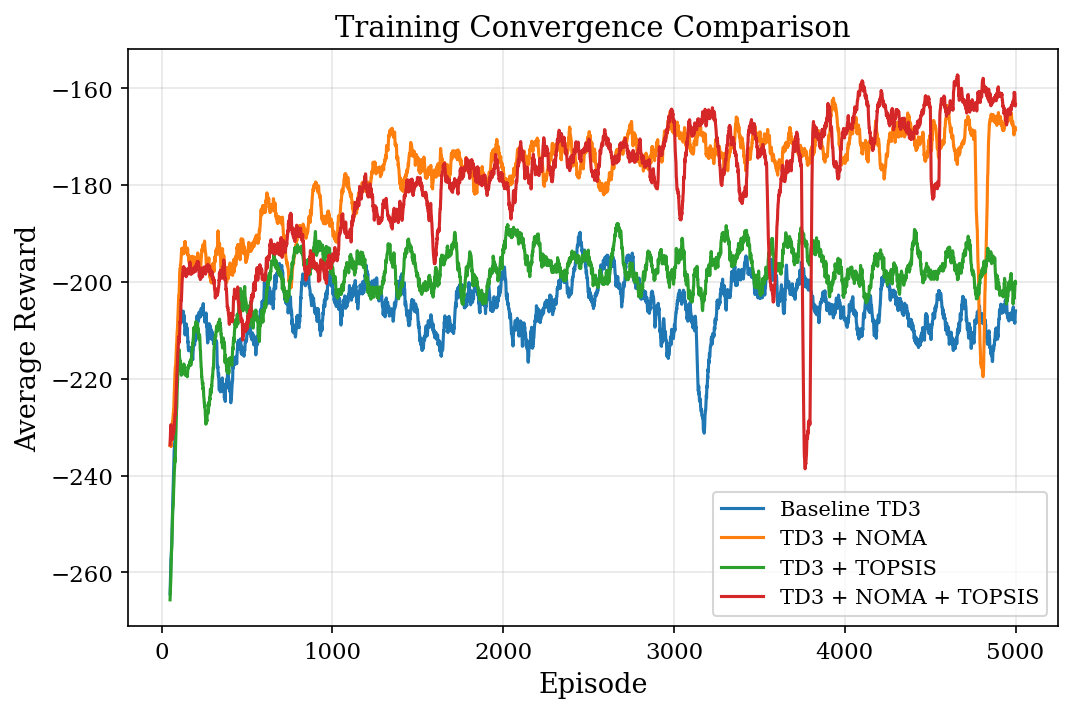

Saved: /content/drive/MyDrive/PLOTS/MAP1/training_reward.png


In [15]:
# Plot 1: Training Reward Convergence
fig, ax = plt.subplots(figsize=(8, 5))

for name in PATHS:
    if name not in train_data:
        continue
    rewards = train_data[name]['episode_rewards']
    smoothed = smooth(rewards, window=50)
    episodes = np.arange(len(smoothed)) + 50  # offset for smoothing window
    ax.plot(episodes, smoothed, label=name, color=COLORS[name], linewidth=1.5)

ax.set_xlabel('Episode')
ax.set_ylabel('Average Reward')
ax.set_title('Training Convergence Comparison')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

save_path = os.path.join(SAVE_DIR, 'training_reward.png')
plt.savefig(save_path)
plt.show()
print(f'Saved: {save_path}')

##Training Cost Convergence

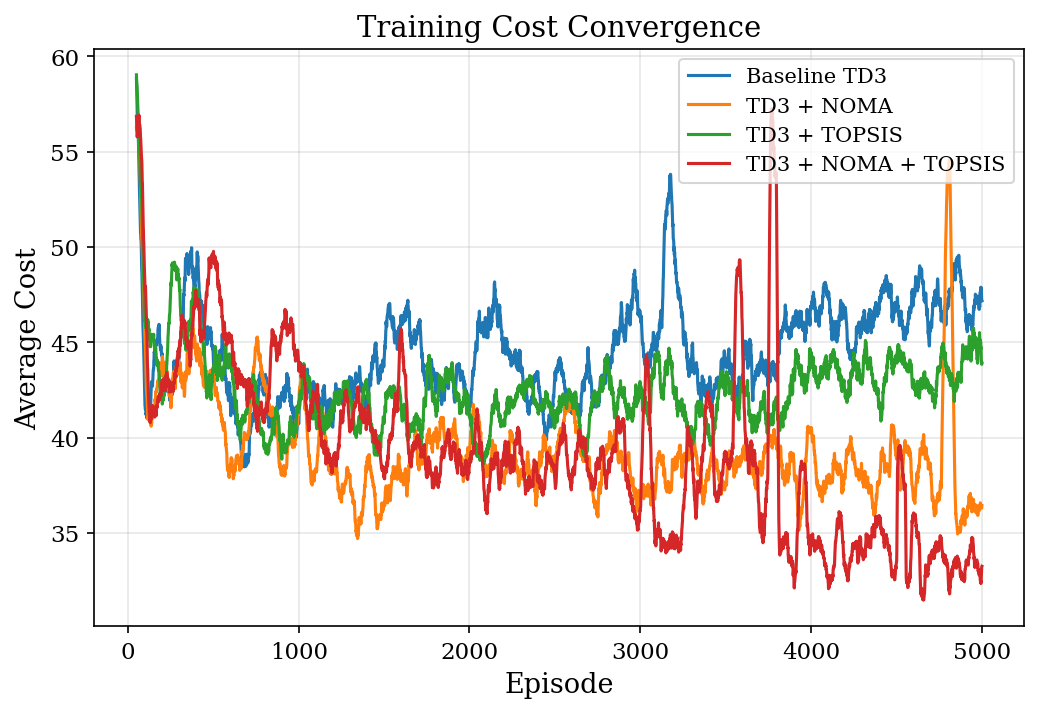

Saved: /content/drive/MyDrive/PLOTS/MAP1/training_cost.png


In [16]:
# Plot 2: Training Cost Convergence
fig, ax = plt.subplots(figsize=(8, 5))

for name in PATHS:
    if name not in train_data:
        continue
    costs = train_data[name]['episode_costs']
    smoothed = smooth(costs, window=50)
    episodes = np.arange(len(smoothed)) + 50
    ax.plot(episodes, smoothed, label=name, color=COLORS[name], linewidth=1.5)

ax.set_xlabel('Episode')
ax.set_ylabel('Average Cost')
ax.set_title('Training Cost Convergence')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

save_path = os.path.join(SAVE_DIR, 'training_cost.png')
plt.savefig(save_path)
plt.show()
print(f'Saved: {save_path}')

## Ablation Study — Evaluation Metrics Bar Chart

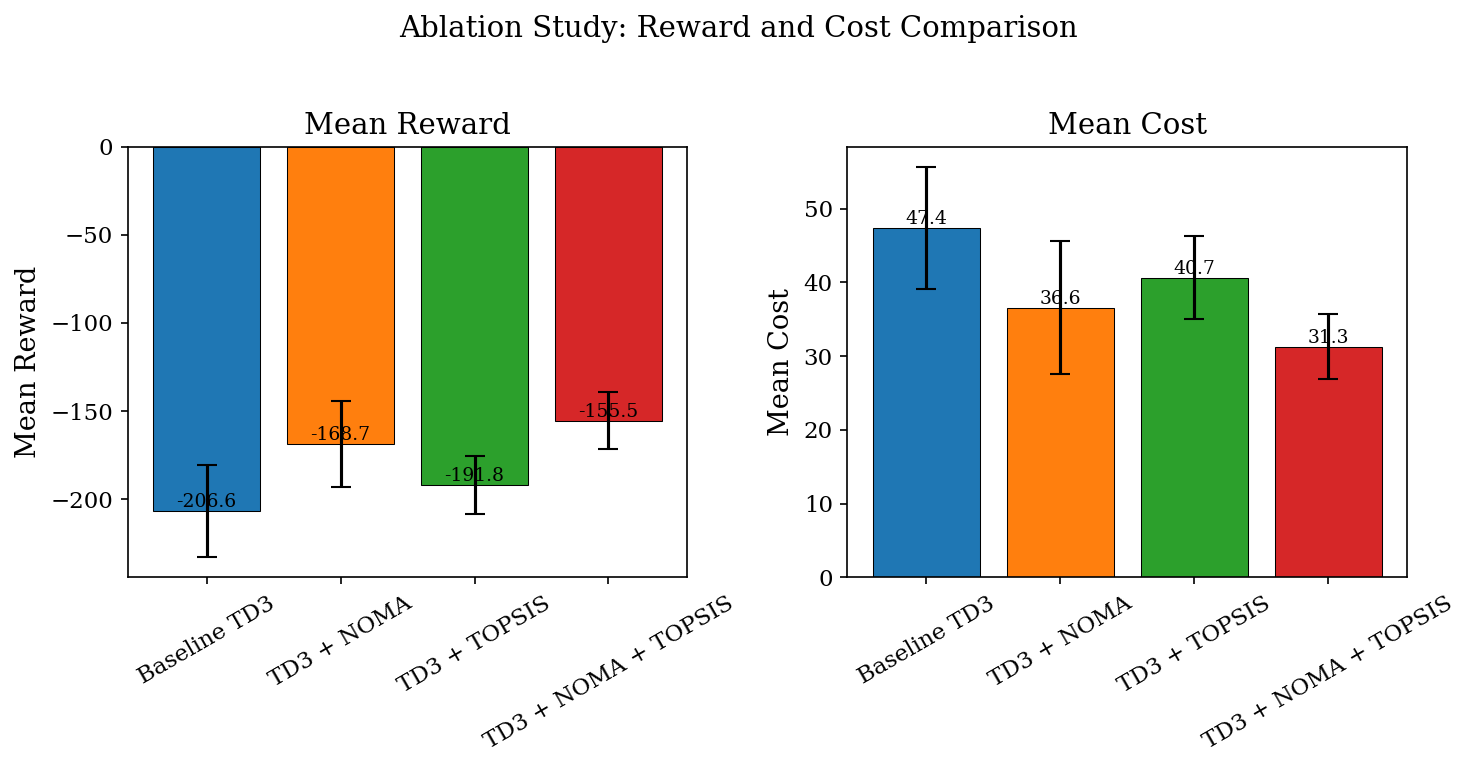

Saved: /content/drive/MyDrive/PLOTS/MAP1/ablation_reward_cost.png


In [17]:
# Ablation Bar Chart — Reward, Cost
methods = [name for name in PATHS if name in eval_data]
metrics = ['mean_reward', 'mean_cost']
labels = ['Mean Reward', 'Mean Cost']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for idx, (metric, label) in enumerate(zip(metrics, labels)):
    values = [eval_data[m][metric] for m in methods]

    # Add std as error bars if available
    std_key = metric.replace('mean_', 'std_')
    errors = [eval_data[m].get(std_key, 0) for m in methods]

    bars = axes[idx].bar(
        methods,
        values,
        color=[COLORS[m] for m in methods],
        yerr=errors,
        capsize=5,
        edgecolor='black',
        linewidth=0.5
    )

    axes[idx].set_ylabel(label)
    axes[idx].set_title(label)
    axes[idx].tick_params(axis='x', rotation=30)

    # Add value labels
    for bar, val in zip(bars, values):
        axes[idx].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{val:.1f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.suptitle('Ablation Study: Reward and Cost Comparison', fontsize=14, y=1.02)
plt.tight_layout()

save_path = os.path.join(SAVE_DIR, 'ablation_reward_cost.png')
plt.savefig(save_path)
plt.show()

print(f'Saved: {save_path}')

## Cost Component Breakdown (Stacked Bar)

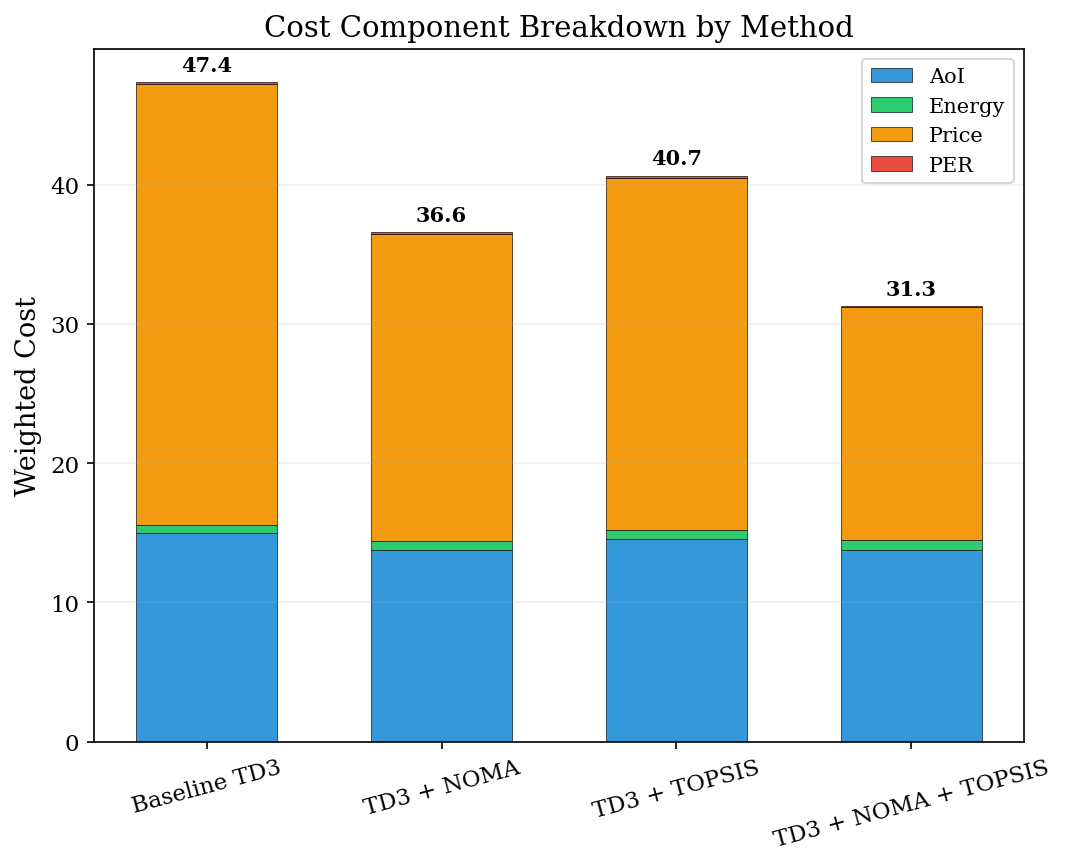

Saved: /content/drive/MyDrive/PLOTS/MAP1/cost_breakdown.png


In [18]:
# Cost Component Breakdown — Stacked Bar
methods = [name for name in PATHS if name in eval_data]
components = ['mean_comp_aoi', 'mean_comp_energy', 'mean_comp_price', 'mean_comp_per']
comp_labels = ['AoI', 'Energy', 'Price', 'PER']
comp_colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(methods))
width = 0.6
bottom = np.zeros(len(methods))

for comp, clabel, color in zip(components, comp_labels, comp_colors):
    values = [eval_data[m].get(comp, 0) for m in methods]
    ax.bar(x, values, width, bottom=bottom, label=clabel, color=color, edgecolor='black', linewidth=0.3)
    bottom += np.array(values)

# Add total cost labels on top
for i, total in enumerate(bottom):
    ax.text(i, total + 0.5, f'{total:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=15)
ax.set_ylabel('Weighted Cost')
ax.set_title('Cost Component Breakdown by Method')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.2, axis='y')

save_path = os.path.join(SAVE_DIR, 'cost_breakdown.png')
plt.savefig(save_path)
plt.show()
print(f'Saved: {save_path}')

## Percentage Improvement Table

In [19]:
methods = [name for name in PATHS if name in eval_data]

if 'Baseline TD3' in eval_data:
    base = eval_data['Baseline TD3']
    compare_metrics = [
        ('mean_reward', 'Mean Reward', True),   # higher is better
        ('mean_cost', 'Mean Cost', False),       # lower is better
        ('mean_penalty', 'Mean Penalty', False),
        ('mean_aoi', 'AoI', False),
        ('mean_energy', 'Energy', False),
        ('mean_price', 'Price', False),
        ('mean_per', 'PER', False),
    ]

    print(f'{"Metric":<15}', end='')
    for m in methods:
        print(f'{m:>16}', end='')
    print()
    print('-' * (15 + 16 * len(methods)))

    table_data = []
    for metric, label, higher_better in compare_metrics:
        row = [label]
        print(f'{label:<15}', end='')
        for m in methods:
            val = eval_data[m].get(metric, 0)
            base_val = base.get(metric, 0)
            if m == 'Baseline TD3':
                print(f'{val:>13.2f}  -', end='')
                row.append(f'{val:.2f}')
            else:
                if abs(base_val) > 1e-6:
                    if higher_better:
                        pct = ((val - base_val) / abs(base_val)) * 100
                    else:
                        pct = ((base_val - val) / abs(base_val)) * 100
                    sign = '+' if pct > 0 else ''
                    print(f'{val:>9.2f} {sign}{pct:.1f}%', end='')
                    row.append(f'{val:.2f} ({sign}{pct:.1f}%)')
                else:
                    print(f'{val:>13.2f}  -', end='')
                    row.append(f'{val:.2f}')
        print()
        table_data.append(row)

    print('\n(Positive % = improvement over Baseline TD3)')
else:
    print('Baseline TD3 evaluation data not found. Cannot compute improvements.')

Metric             Baseline TD3      TD3 + NOMA    TD3 + TOPSISTD3 + NOMA + TOPSIS
-------------------------------------------------------------------------------
Mean Reward          -206.59  -  -168.66 +18.4%  -191.81 +7.2%  -155.45 +24.8%
Mean Cost              47.41  -    36.61 +22.8%    40.66 +14.2%    31.32 +33.9%
Mean Penalty          156.44  -   131.46 +16.0%   148.75 +4.9%   123.78 +20.9%
AoI                     0.75  -     0.69 +8.3%     0.73 +2.7%     0.69 +7.9%
Energy                  0.03  -     0.03 -5.5%     0.03 -5.1%     0.03 -10.5%
Price                   1.58  -     1.10 +30.3%     1.26 +20.1%     0.84 +47.1%
PER                     0.48  -     0.43 +9.0%     0.46 +4.4%     0.33 +30.6%

(Positive % = improvement over Baseline TD3)


## Loss Convergence

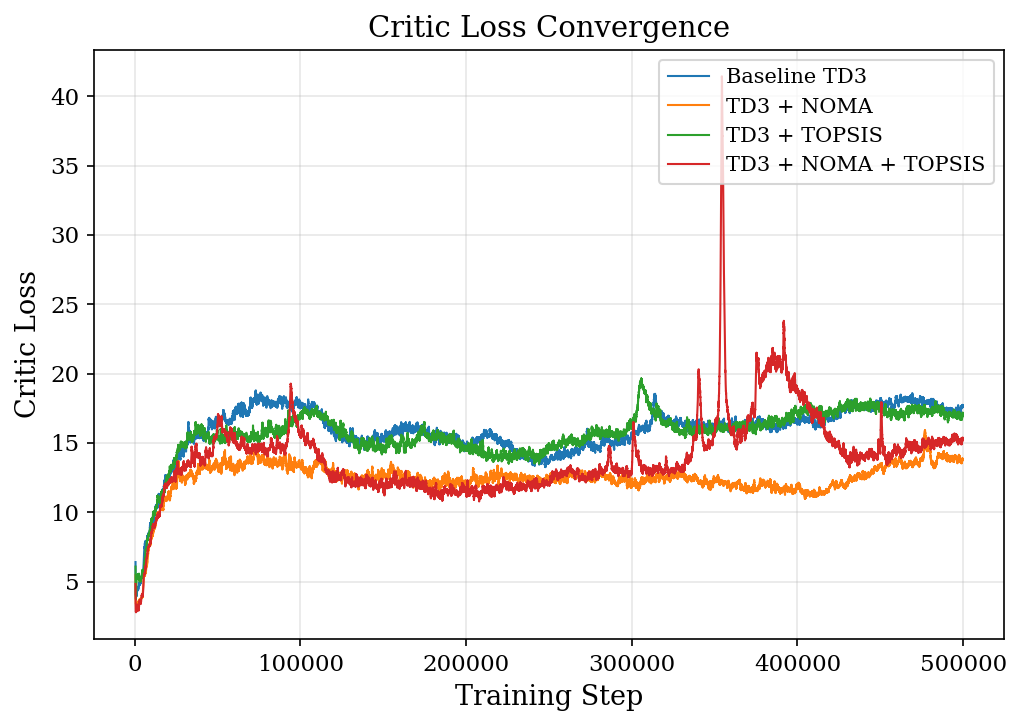

Saved: /content/drive/MyDrive/PLOTS/MAP1/loss.png


In [20]:
# Plot: Critic Loss
fig, ax = plt.subplots(figsize=(7, 5))

for name in PATHS:
    if name not in train_data:
        continue

    cl = train_data[name].get('critic_losses', [])
    if cl:
        smoothed = smooth(cl, window=500)
        steps = np.arange(len(smoothed)) + 500

        ax.plot(
            steps,
            smoothed,
            label=name,
            color=COLORS[name],
            linewidth=1
        )

ax.set_xlabel('Training Step')
ax.set_ylabel('Critic Loss')
ax.set_title('Critic Loss Convergence')

ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()

save_path = os.path.join(SAVE_DIR, 'loss.png')
plt.savefig(save_path)

plt.show()

print(f'Saved: {save_path}')